# Customer Churn Prediction
## Individual Preprocessing Technique: Feature Engineering
### Member: Thishan-IT25103171

This notebook follows the structure of the uploaded **Feature Engineering** reference notebook and is adapted to the **Bank Customer Churn** dataset.

The purpose of this notebook is to create meaningful new predictor variables from the existing customer information without using the target variable `Exited`.

### Engineered Features
1. `BalanceSalaryRatio`
2. `TenureByAge`
3. `BalancePerProduct`
4. `ProductsPerTenure`
5. `ActiveWithCard`
6. `IsZeroBalance`

The target variable `Exited` is **not** used to construct any engineered feature in order to avoid target leakage.


## Feature Engineering

Feature engineering creates new variables from existing predictors so that machine-learning models can capture useful relationships more easily.

For this churn dataset, the engineered features focus on:

- customer financial relationships
- customer tenure relative to age
- product usage
- customer engagement
- zero-balance behavior


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from pathlib import Path

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load the Dataset

According to the group order, Feature Engineering comes after Class Imbalance Handling.

Therefore, this notebook first looks for:

`04_balanced_churn_data.csv`

Because the class-imbalance notebook may not have been created yet, it can also use:

`03_outlier_removed_churn_data.csv`

as a temporary input.


In [2]:
from google.colab import files

uploaded = files.upload()

Saving 04_balanced_churn_data.csv to 04_balanced_churn_data.csv


In [3]:
possible_paths = [
    Path("/content/04_balanced_churn_data.csv"),
    Path("04_balanced_churn_data.csv"),
    Path("/content/03_outlier_removed_churn_data.csv"),
    Path("03_outlier_removed_churn_data.csv"),
    Path("/content/02_encoded_churn_data.csv"),
    Path("02_encoded_churn_data.csv")
]

file_path = None

for path in possible_paths:
    if path.exists():
        file_path = path
        break

if file_path is None:
    raise FileNotFoundError(
        "No previous preprocessing output was found. "
        "Upload 04_balanced_churn_data.csv or "
        "03_outlier_removed_churn_data.csv."
    )

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Loaded file:", file_path)
print("Shape:", df.shape)

df.head()


Dataset loaded successfully!
Loaded file: /content/04_balanced_churn_data.csv
Shape: (15354, 12)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Exited
0,619,0,42,2,0.00,1,1,1,101348.88,0,0,1
1,608,0,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,0,42,8,159660.80,3,1,0,113931.57,0,0,1
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,1,0


## 2. Initial Dataset Inspection


In [4]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Column names:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Exited']

Data types:
CreditScore            int64
Gender                 int64
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Geography_Germany      int64
Geography_Spain        int64
Exited                 int64
dtype: object

Missing values:
CreditScore          0
Gender               0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Geography_Germany    0
Geography_Spain      0
Exited               0
dtype: int64

Number of duplicate rows:
5786


## 3. EDA Before Feature Engineering

Before creating new features, we visualize the main source variables used for feature engineering.


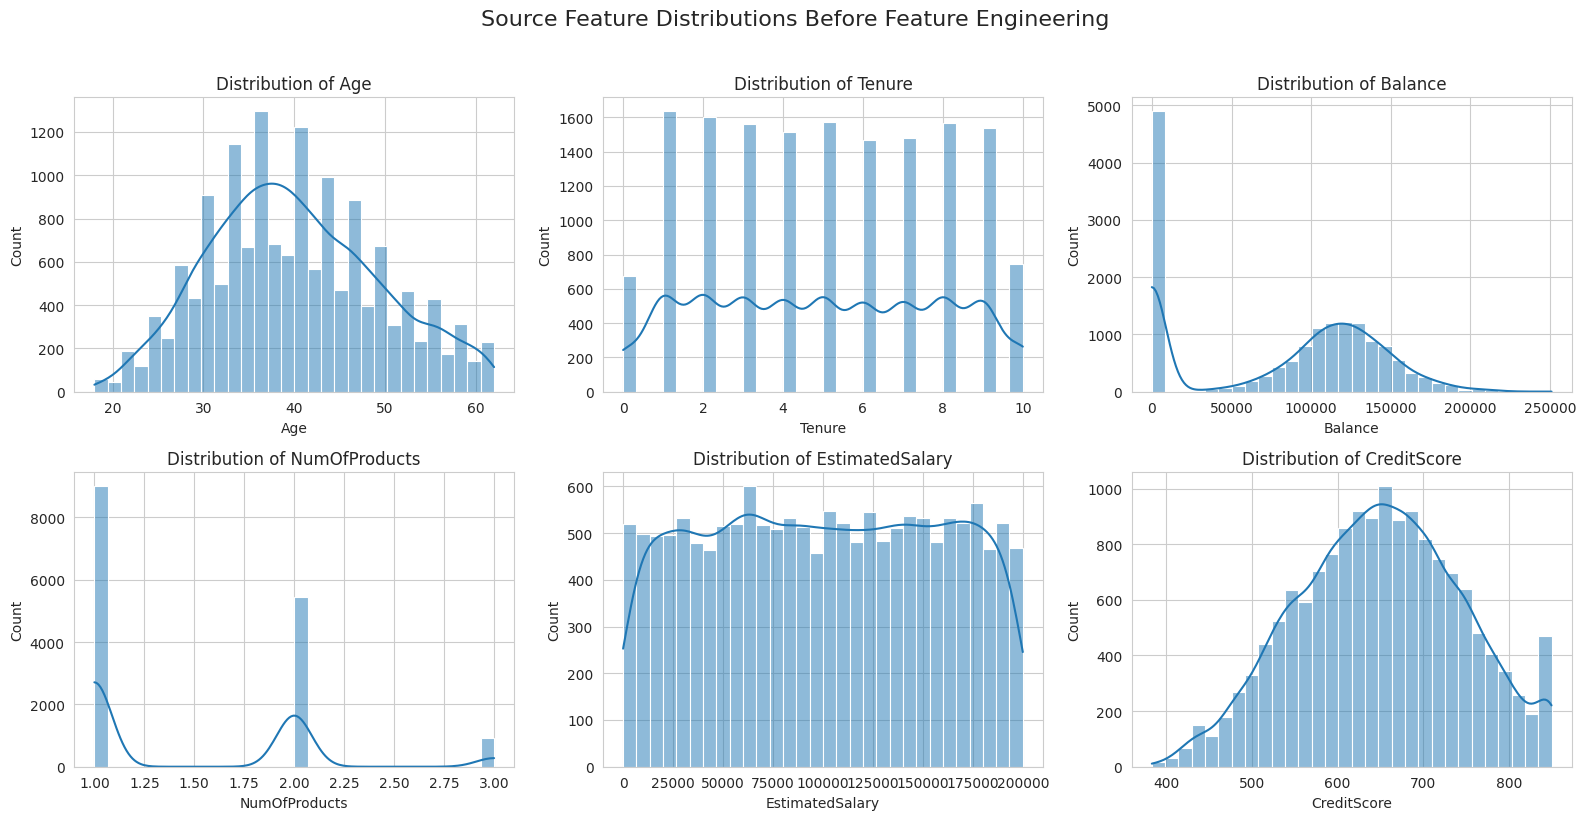

In [5]:
source_features = [
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary",
    "CreditScore"
]

source_features = [
    col for col in source_features
    if col in df.columns
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(source_features):
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {col}")

for j in range(len(source_features), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Source Feature Distributions Before Feature Engineering",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()


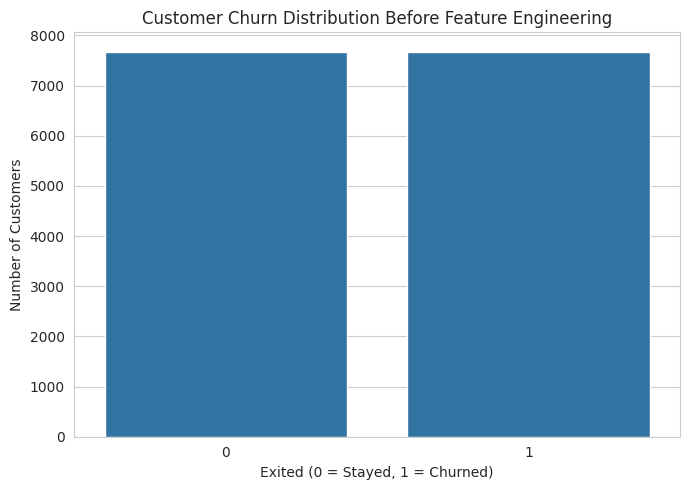

In [6]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Exited"
)

plt.title("Customer Churn Distribution Before Feature Engineering")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


## 4. Keep the Original Dataset Unchanged

A copy is created before feature engineering so that the original input can still be compared with the engineered dataset.


In [7]:
df_fe = df.copy()

print("Original shape:", df.shape)
print("Working copy shape:", df_fe.shape)


Original shape: (15354, 12)
Working copy shape: (15354, 12)


## 5. Feature 1 — Balance to Salary Ratio

`BalanceSalaryRatio` compares the customer's account balance with their estimated salary.

A larger value means the customer's balance is relatively high compared with their estimated salary.


In [8]:
salary_safe = df_fe["EstimatedSalary"].replace(0, np.nan)

df_fe["BalanceSalaryRatio"] = (
    df_fe["Balance"] / salary_safe
).replace([np.inf, -np.inf], np.nan).fillna(0)

print("BalanceSalaryRatio feature created!")

print("Minimum:", df_fe["BalanceSalaryRatio"].min())
print("Maximum:", df_fe["BalanceSalaryRatio"].max())

display(
    df_fe[
        ["Balance", "EstimatedSalary", "BalanceSalaryRatio"]
    ].head(10)
)


BalanceSalaryRatio feature created!
Minimum: 0.0
Maximum: 10614.655440414508


,Balance,EstimatedSalary,BalanceSalaryRatio
0,0.00,101348.88,0.000000
1,83807.86,112542.58,0.744677
2,159660.80,113931.57,1.401375
3,0.00,93826.63,0.000000
4,125510.82,79084.10,1.587055
5,113755.78,149756.71,0.759604
6,0.00,10062.80,0.000000
7,142051.07,74940.50,1.895518
8,134603.88,71725.73,1.876647
9,102016.72,80181.12,1.272328


## 6. Feature 2 — Tenure Relative to Age

`TenureByAge` represents how long a customer has been with the bank relative to their age.

This may provide a better representation of customer loyalty than tenure alone.


In [9]:
age_safe = df_fe["Age"].replace(0, np.nan)

df_fe["TenureByAge"] = (
    df_fe["Tenure"] / age_safe
).replace([np.inf, -np.inf], np.nan).fillna(0)

print("TenureByAge feature created!")

print("Minimum:", df_fe["TenureByAge"].min())
print("Maximum:", df_fe["TenureByAge"].max())

display(
    df_fe[
        ["Tenure", "Age", "TenureByAge"]
    ].head(10)
)


TenureByAge feature created!
Minimum: 0.0
Maximum: 0.5555555555555556


,Tenure,Age,TenureByAge
0,2,42,0.047619
1,1,41,0.024390
2,8,42,0.190476
3,1,39,0.025641
4,2,43,0.046512
5,8,44,0.181818
6,7,50,0.140000
7,4,44,0.090909
8,2,27,0.074074
9,6,31,0.193548


## 7. Feature 3 — Balance per Product

`BalancePerProduct` distributes the customer's balance across the number of bank products they use.

It can indicate how strongly a customer's financial activity is concentrated in each product.


In [10]:
products_safe = df_fe["NumOfProducts"].replace(0, np.nan)

df_fe["BalancePerProduct"] = (
    df_fe["Balance"] / products_safe
).replace([np.inf, -np.inf], np.nan).fillna(0)

print("BalancePerProduct feature created!")

print("Minimum:", df_fe["BalancePerProduct"].min())
print("Maximum:", df_fe["BalancePerProduct"].max())

display(
    df_fe[
        ["Balance", "NumOfProducts", "BalancePerProduct"]
    ].head(10)
)


BalancePerProduct feature created!
Minimum: 0.0
Maximum: 238387.56


,Balance,NumOfProducts,BalancePerProduct
0,0.00,1,0.000000
1,83807.86,1,83807.860000
2,159660.80,3,53220.266667
3,0.00,2,0.000000
4,125510.82,1,125510.820000
5,113755.78,2,56877.890000
6,0.00,2,0.000000
7,142051.07,2,71025.535000
8,134603.88,1,134603.880000
9,102016.72,2,51008.360000


## 8. Feature 4 — Products per Tenure

`ProductsPerTenure` represents product usage relative to the number of years the customer has been with the bank.

`Tenure + 1` is used so that customers with zero tenure can still be included safely.


In [11]:
df_fe["ProductsPerTenure"] = (
    df_fe["NumOfProducts"] / (df_fe["Tenure"] + 1)
)

print("ProductsPerTenure feature created!")

print("Minimum:", df_fe["ProductsPerTenure"].min())
print("Maximum:", df_fe["ProductsPerTenure"].max())

display(
    df_fe[
        ["NumOfProducts", "Tenure", "ProductsPerTenure"]
    ].head(10)
)


ProductsPerTenure feature created!
Minimum: 0.09090909090909091
Maximum: 3.0


,NumOfProducts,Tenure,ProductsPerTenure
0,1,2,0.333333
1,1,1,0.500000
2,3,8,0.333333
3,2,1,1.000000
4,1,2,0.333333
5,2,8,0.222222
6,2,7,0.250000
7,2,4,0.400000
8,1,2,0.333333
9,2,6,0.285714


## 9. Feature 5 — Active Customer with Credit Card

`ActiveWithCard` is an interaction feature.

It becomes:

- `1` when the customer is active **and** has a credit card
- `0` otherwise

This combines two customer-engagement indicators into one feature.


In [12]:
df_fe["ActiveWithCard"] = (
    df_fe["IsActiveMember"] * df_fe["HasCrCard"]
).astype(int)

print("ActiveWithCard feature created!")

print(df_fe["ActiveWithCard"].value_counts().sort_index())

display(
    df_fe[
        ["IsActiveMember", "HasCrCard", "ActiveWithCard"]
    ].head(10)
)


ActiveWithCard feature created!
ActiveWithCard
0    10632
1     4722
Name: count, dtype: int64


,IsActiveMember,HasCrCard,ActiveWithCard
0,1,1,1
1,1,0,0
2,0,1,0
3,0,0,0
4,1,1,1
5,0,1,0
6,1,1,1
7,1,0,0
8,1,1,1
9,0,0,0


## 10. Feature 6 — Zero Balance Indicator

`IsZeroBalance` identifies customers who have no account balance.

- `1` → Balance is exactly zero
- `0` → Balance is greater than zero


In [13]:
df_fe["IsZeroBalance"] = (
    df_fe["Balance"] == 0
).astype(int)

print("IsZeroBalance feature created!")

print(df_fe["IsZeroBalance"].value_counts().sort_index())

display(
    df_fe[
        ["Balance", "IsZeroBalance"]
    ].head(10)
)


IsZeroBalance feature created!
IsZeroBalance
0    10465
1     4889
Name: count, dtype: int64


,Balance,IsZeroBalance
0,0.00,1
1,83807.86,0
2,159660.80,0
3,0.00,1
4,125510.82,0
5,113755.78,0
6,0.00,1
7,142051.07,0
8,134603.88,0
9,102016.72,0


## 11. Validate the Engineered Features

We verify:

- all six engineered features exist
- no missing values were introduced
- no infinite values were introduced
- the number of rows has not changed


In [14]:
engineered_features = [
    "BalanceSalaryRatio",
    "TenureByAge",
    "BalancePerProduct",
    "ProductsPerTenure",
    "ActiveWithCard",
    "IsZeroBalance"
]

print("Number of engineered features:", len(engineered_features))

print("\nDataset shape before Feature Engineering:", df.shape)
print("Dataset shape after Feature Engineering :", df_fe.shape)

print("\nMissing values in engineered features:")
print(df_fe[engineered_features].isnull().sum())

print("\nInfinite values in engineered features:")
print(
    np.isinf(
        df_fe[engineered_features]
        .select_dtypes(include=np.number)
    ).sum()
)

display(df_fe[engineered_features].head())


Number of engineered features: 6

Dataset shape before Feature Engineering: (15354, 12)
Dataset shape after Feature Engineering : (15354, 18)

Missing values in engineered features:
BalanceSalaryRatio    0
TenureByAge           0
BalancePerProduct     0
ProductsPerTenure     0
ActiveWithCard        0
IsZeroBalance         0
dtype: int64

Infinite values in engineered features:
BalanceSalaryRatio    0
TenureByAge           0
BalancePerProduct     0
ProductsPerTenure     0
ActiveWithCard        0
IsZeroBalance         0
dtype: int64


,BalanceSalaryRatio,TenureByAge,BalancePerProduct,ProductsPerTenure,ActiveWithCard,IsZeroBalance
0,0.000000,0.047619,0.000000,0.333333,1,1
1,0.744677,0.024390,83807.860000,0.500000,0,0
2,1.401375,0.190476,53220.266667,0.333333,0,0
3,0.000000,0.025641,0.000000,1.000000,0,1
4,1.587055,0.046512,125510.820000,0.333333,1,0


## 12. EDA — Distributions of Engineered Features

These graphs show the distributions of the six newly created features.


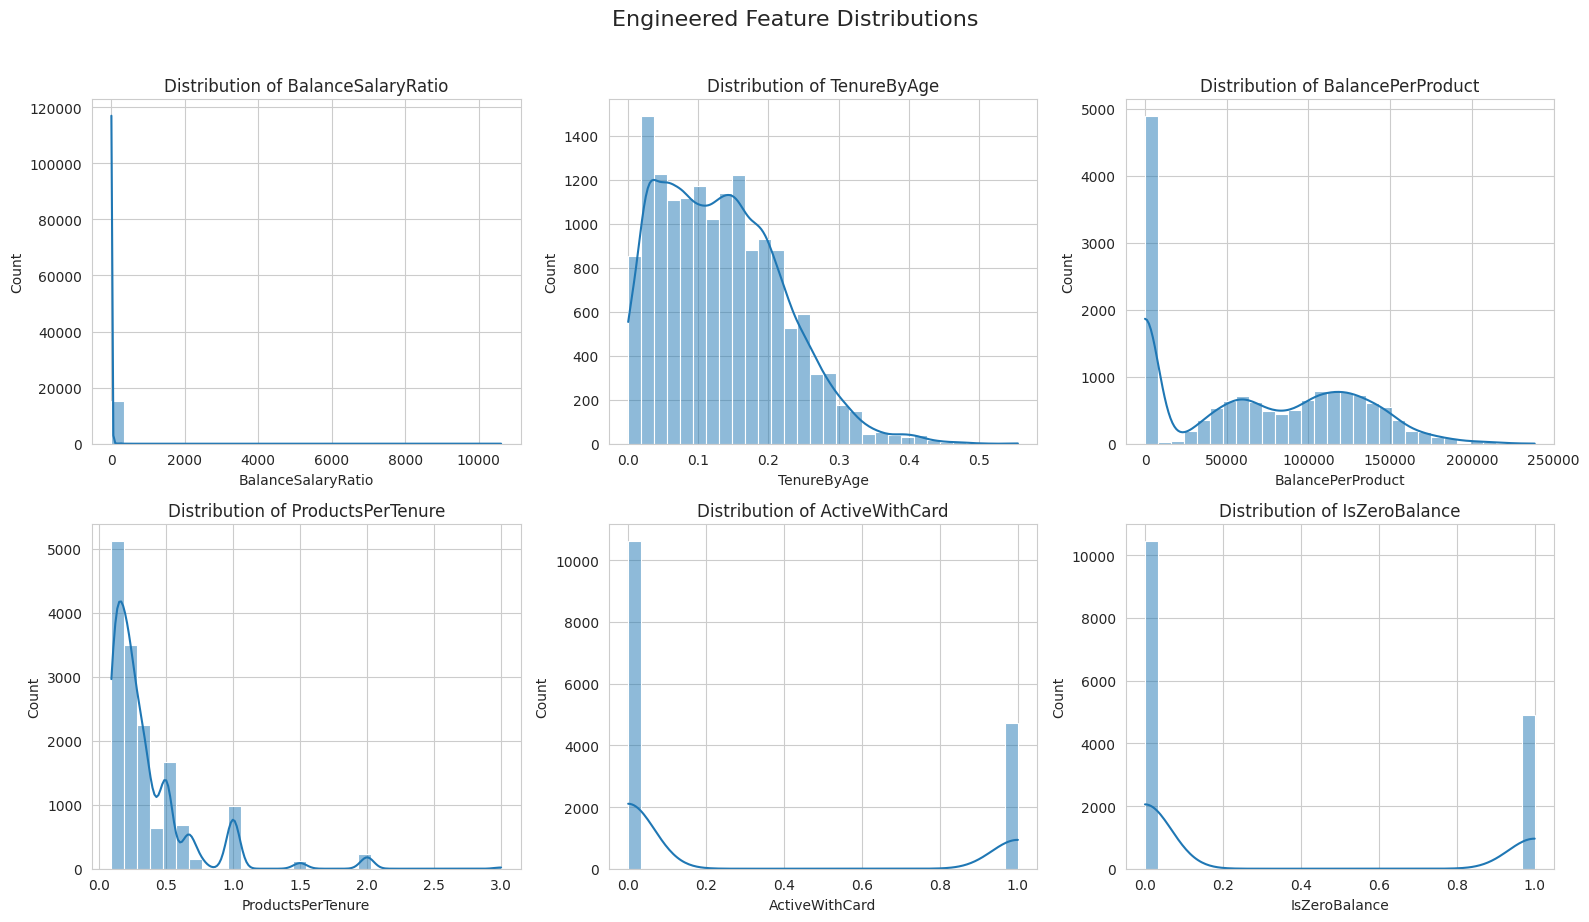

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(engineered_features):
    sns.histplot(
        data=df_fe,
        x=col,
        bins=30,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {col}")

plt.suptitle(
    "Engineered Feature Distributions",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()


## 13. Correlation of Engineered Features with Churn

This analysis checks the linear relationship between each engineered feature and the target variable `Exited`.

A weak linear correlation does **not** automatically mean that a feature is useless, because machine-learning models can also learn non-linear patterns and feature interactions.


Correlation of engineered features with Exited:


,Correlation with Exited
BalancePerProduct,0.149048
BalanceSalaryRatio,0.016781
ProductsPerTenure,-0.025703
IsZeroBalance,-0.154763
TenureByAge,-0.160460
ActiveWithCard,-0.160892


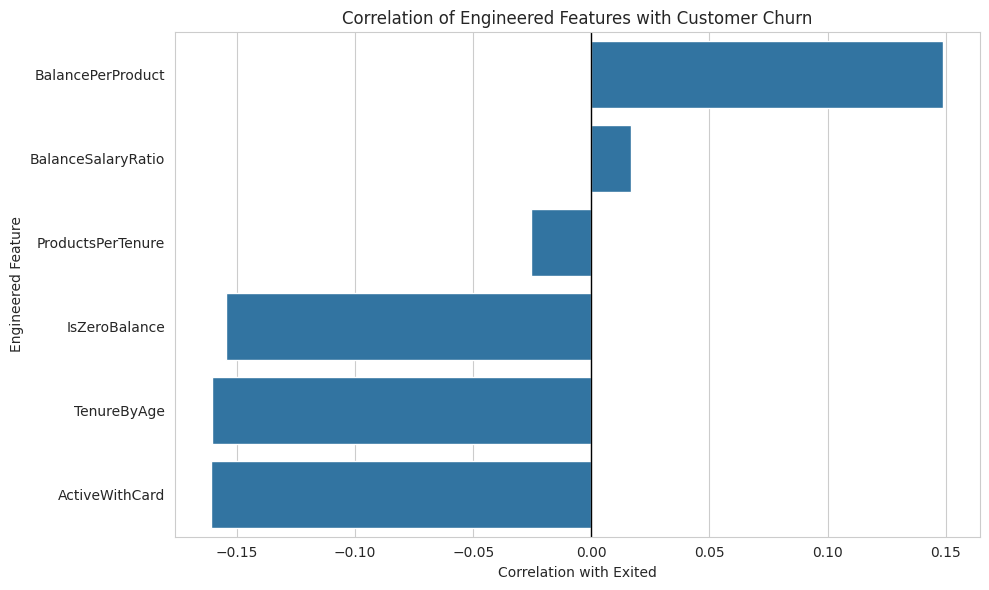

In [16]:
correlations = (
    df_fe[engineered_features + ["Exited"]]
    .corr()["Exited"]
    .drop("Exited")
    .sort_values(ascending=False)
)

print("Correlation of engineered features with Exited:")
display(
    correlations.to_frame(
        name="Correlation with Exited"
    )
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=correlations.values,
    y=correlations.index
)

plt.title("Correlation of Engineered Features with Customer Churn")
plt.xlabel("Correlation with Exited")
plt.ylabel("Engineered Feature")

plt.axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()


## 14. EDA — Engineered Features by Churn Status

Boxplots compare the engineered numerical features between customers who stayed and customers who churned.


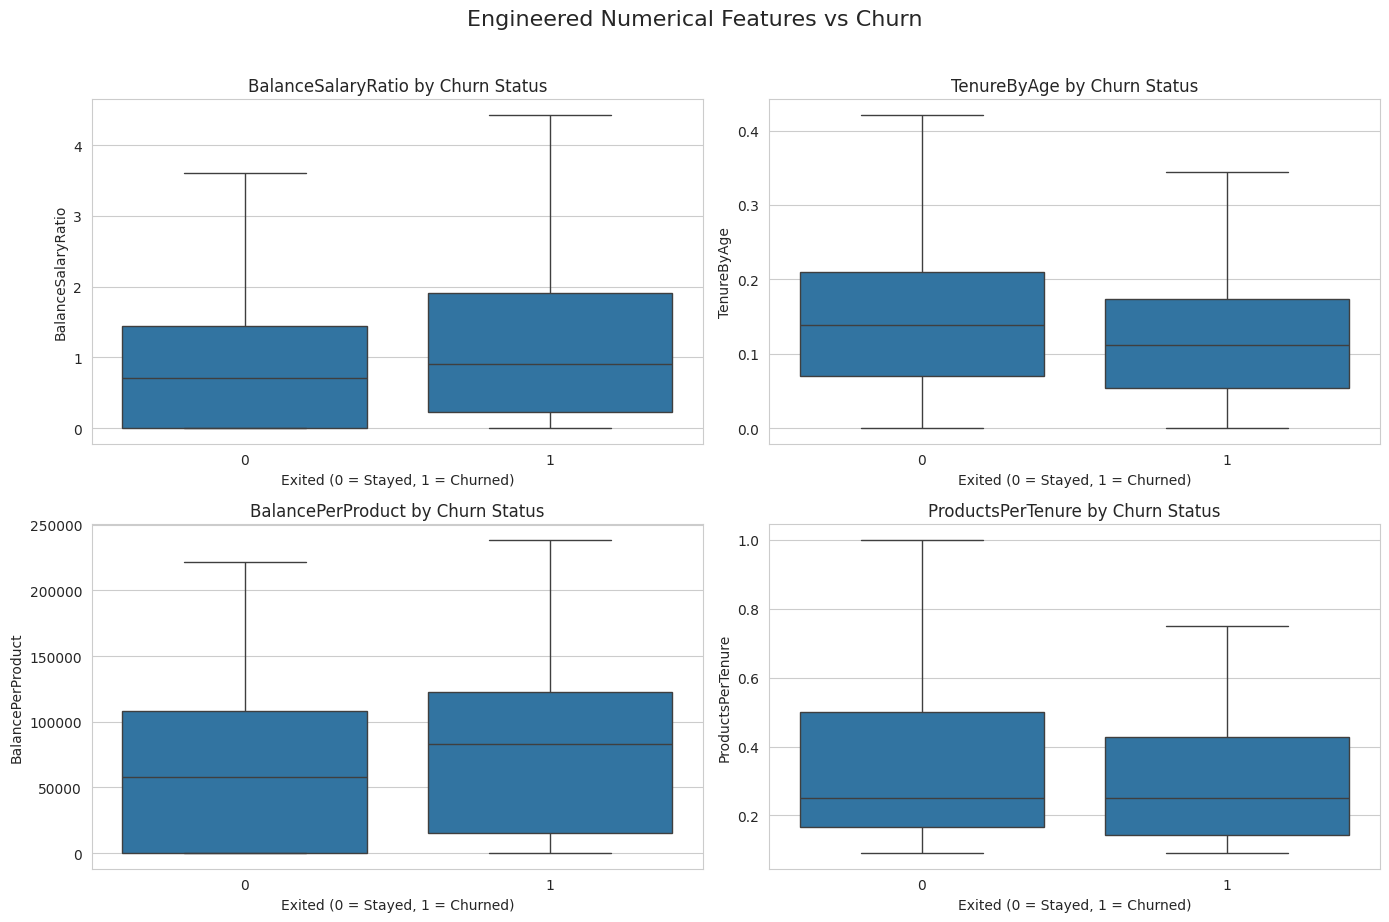

In [17]:
continuous_engineered = [
    "BalanceSalaryRatio",
    "TenureByAge",
    "BalancePerProduct",
    "ProductsPerTenure"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(continuous_engineered):
    sns.boxplot(
        data=df_fe,
        x="Exited",
        y=col,
        showfliers=False,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} by Churn Status")
    axes[i].set_xlabel("Exited (0 = Stayed, 1 = Churned)")

plt.suptitle(
    "Engineered Numerical Features vs Churn",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()


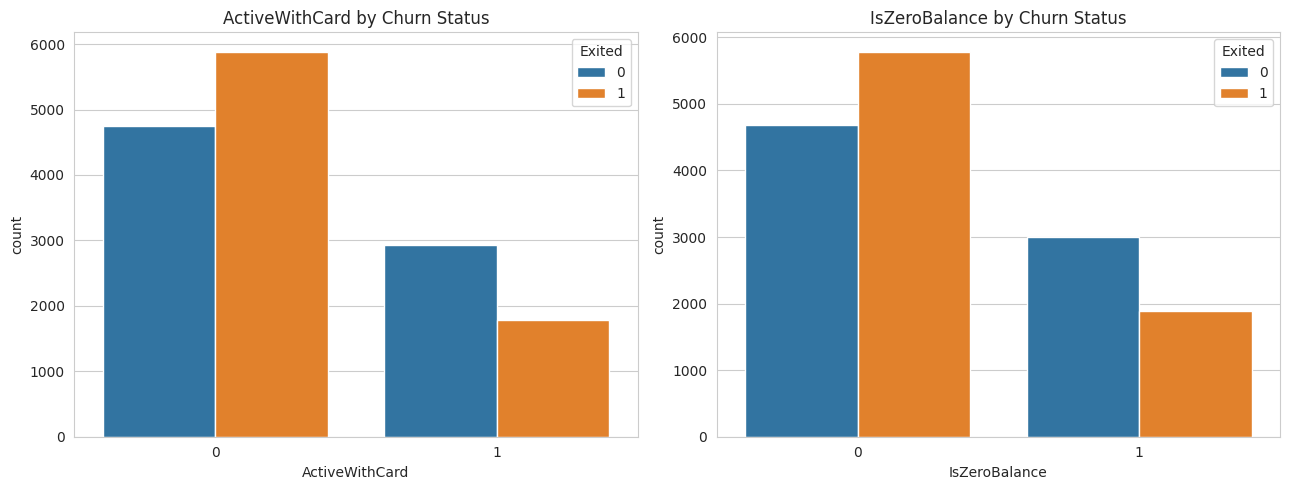

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(
    data=df_fe,
    x="ActiveWithCard",
    hue="Exited",
    ax=axes[0]
)
axes[0].set_title("ActiveWithCard by Churn Status")
axes[0].set_xlabel("ActiveWithCard")

sns.countplot(
    data=df_fe,
    x="IsZeroBalance",
    hue="Exited",
    ax=axes[1]
)
axes[1].set_title("IsZeroBalance by Churn Status")
axes[1].set_xlabel("IsZeroBalance")

plt.tight_layout()
plt.show()


### EDA Interpretation

The engineered-feature visualizations help us compare customer groups after feature creation.

- Ratio features capture relationships that are not directly visible from the original columns.
- Interaction features can represent combined customer behavior.
- Binary indicator features make important customer conditions easier for a model to identify.
- Correlation values measure only linear relationships; a low correlation does not necessarily mean a feature should be removed.


## 15. Correlation Heatmap


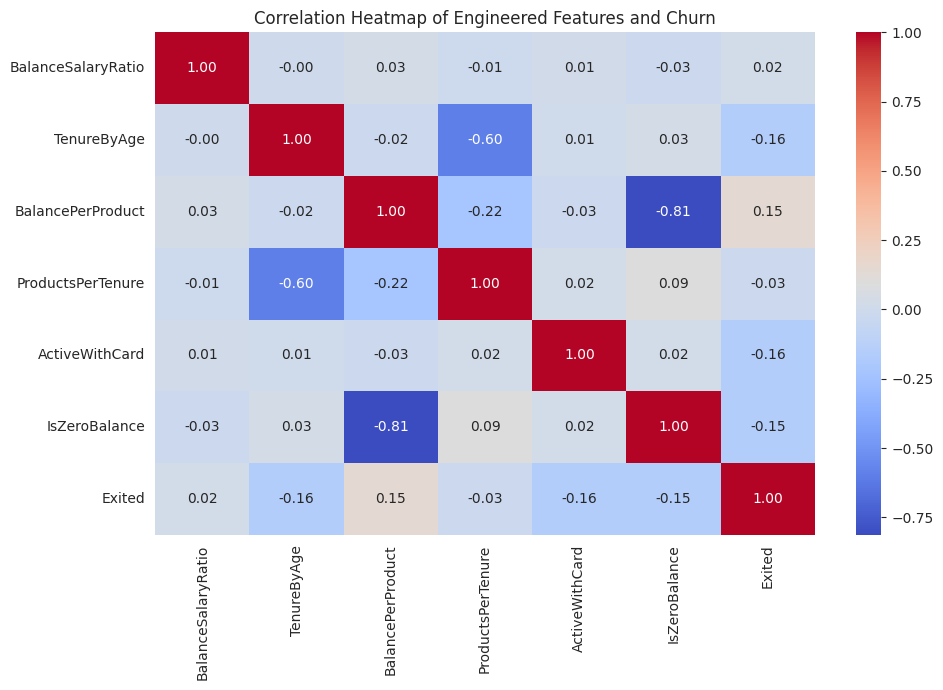

In [19]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df_fe[engineered_features + ["Exited"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Engineered Features and Churn")
plt.tight_layout()
plt.show()


## 16. Original vs Feature-Engineered Predictors

This section compares the predictor set before and after adding the six new features.

`Exited` is excluded because it is the target variable.


In [20]:
y = df_fe["Exited"]

baseline_features = [
    col for col in df.columns
    if col != "Exited"
]

X_baseline = df_fe[baseline_features]

X_engineered = df_fe[
    baseline_features + engineered_features
]

print("Baseline number of features:", X_baseline.shape[1])
print("Engineered number of features:", X_engineered.shape[1])

print("\nBaseline shape:", X_baseline.shape)
print("Engineered shape:", X_engineered.shape)
print("Target shape:", y.shape)


Baseline number of features: 11
Engineered number of features: 17

Baseline shape: (15354, 11)
Engineered shape: (15354, 17)
Target shape: (15354,)


## 17. Feature Engineering Summary


In [21]:
feature_summary = pd.DataFrame({
    "Engineered Feature": [
        "BalanceSalaryRatio",
        "TenureByAge",
        "BalancePerProduct",
        "ProductsPerTenure",
        "ActiveWithCard",
        "IsZeroBalance"
    ],

    "Derived From": [
        "Balance, EstimatedSalary",
        "Tenure, Age",
        "Balance, NumOfProducts",
        "NumOfProducts, Tenure",
        "IsActiveMember, HasCrCard",
        "Balance"
    ],

    "Purpose": [
        "Represent account balance relative to estimated salary",
        "Represent customer tenure relative to customer age",
        "Represent balance distributed across bank products",
        "Represent product usage relative to customer tenure",
        "Capture interaction between active membership and credit-card ownership",
        "Indicate whether the customer has a zero account balance"
    ]
})

display(feature_summary)


,Engineered Feature,Derived From,Purpose
0,BalanceSalaryRatio,"Balance, EstimatedSalary",Represent account balance relative to estimate...
1,TenureByAge,"Tenure, Age",Represent customer tenure relative to customer...
2,BalancePerProduct,"Balance, NumOfProducts",Represent balance distributed across bank prod...
3,ProductsPerTenure,"NumOfProducts, Tenure",Represent product usage relative to customer t...
4,ActiveWithCard,"IsActiveMember, HasCrCard",Capture interaction between active membership ...
5,IsZeroBalance,Balance,Indicate whether the customer has a zero accou...


## 18. Final Validation


In [22]:
print("Final dataset shape:", df_fe.shape)

print("\nTotal missing values:")
print(df_fe.isnull().sum().sum())

print("\nTotal duplicate rows:")
print(df_fe.duplicated().sum())

print("\nEngineered feature data types:")
print(df_fe[engineered_features].dtypes)


Final dataset shape: (15354, 18)

Total missing values:
0

Total duplicate rows:
5786

Engineered feature data types:
BalanceSalaryRatio    float64
TenureByAge           float64
BalancePerProduct     float64
ProductsPerTenure     float64
ActiveWithCard          int64
IsZeroBalance           int64
dtype: object


## 19. Save the Feature-Engineered Dataset

The output of this notebook can be used by the next preprocessing stage:

### Standardization — Fatheen

Output file:

`05_feature_engineered_churn_data.csv`


In [23]:
if Path("/content").exists():
    output_file = "/content/05_feature_engineered_churn_data.csv"
else:
    output_file = "05_feature_engineered_churn_data.csv"

df_fe.to_csv(
    output_file,
    index=False
)

print("Feature-engineered dataset saved successfully!")
print("File:", output_file)
print("Final shape:", df_fe.shape)


Feature-engineered dataset saved successfully!
File: /content/05_feature_engineered_churn_data.csv
Final shape: (15354, 18)


In [24]:
# Optional Google Colab download

try:
    from google.colab import files
    files.download(output_file)
except ImportError:
    print("Google Colab download is not available in this environment.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
from google.colab import files

files.download("05_feature_engineered_churn_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

In this preprocessing stage:

- Six new features were created from existing predictor variables.
- The target variable `Exited` was not used to create any feature.
- No rows were intentionally removed during feature engineering.
- Missing and infinite values were checked after feature creation.
- EDA visualizations were produced for the engineered features.
- Relationships between the new features and churn were examined.
- The completed dataset was saved as `05_feature_engineered_churn_data.csv`.

The dataset is now ready for the next stage: **Standardization**.
